In [1]:
# Mount Drive if not already mounted
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# Load AraPoems dataset
import pandas as pd

arapoems_path = "/content/drive/MyDrive/lsen/AraPoems_Dataset.csv"
df = pd.read_csv(arapoems_path)

print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- Column Names ---")
print(df.columns.tolist())

print("\n--- First 3 Rows ---")
print(df.head(3))

print("\n--- Data Types ---")
print(df.dtypes)

Mounted at /content/drive
--- Dataset Shape ---
Rows: 2090907, Columns: 15

--- Column Names ---
['poem_title', 'first_hemistich', 'second_hemistich', 'poet', 'meter', 'sub_meter', 'البحر', 'جزء البحر', 'era', 'rhyme', 'قافية', 'type_en', 'type_ar', 'link', 'gender']

--- First 3 Rows ---
                         poem_title          first_hemistich  \
0  إيهاً جُدابُ سَيِّدَ الْأَعْرابِ    إيها جداب سيد الأعراب   
1  إيهاً جُدابُ سَيِّدَ الْأَعْرابِ  يا طيب الأحساب والأنساب   
2  إيهاً جُدابُ سَيِّدَ الْأَعْرابِ   بالعزم والحزم وبالعذاب   

           second_hemistich                                    poet  meter  \
0    يا معدن الطعان والضراب  صَفِيَّة بنت ثَعْلَبَة الشَّيْبانِيَّة  rajaz   
1      قم لي مقام سيدي شهاب  صَفِيَّة بنت ثَعْلَبَة الشَّيْبانِيَّة  rajaz   
2  شمر وقم يا ويك في النقاب  صَفِيَّة بنت ثَعْلَبَة الشَّيْبانِيَّة  rajaz   

  sub_meter البحر جزء البحر        era rhyme قافية      type_en type_ar  \
0    majzuu   رجز     مجزوء  Pre_Islam   baa     ب  unspecified  

In [2]:
# Explore the dataset
print("--- Meter Distribution ---")
print(df['meter'].value_counts())

print(f"\n--- Missing Values (Key Columns) ---")
print(f"meter:            {df['meter'].isna().sum()}")
print(f"first_hemistich:  {df['first_hemistich'].isna().sum()}")
print(f"second_hemistich: {df['second_hemistich'].isna().sum()}")
print(f"sub_meter:        {df['sub_meter'].isna().sum()}")

print(f"\n--- Unique Meters ---")
print(sorted(df['meter'].dropna().unique()))

print(f"\n--- Era Distribution ---")
print(df['era'].value_counts())

print(f"\n--- Sub-Meter Distribution (Top 20) ---")
print(df['sub_meter'].value_counts().head(20))

--- Meter Distribution ---
meter
taweel         442763
kamel          406908
baseet         265045
unspecified    179028
khafif         174105
wafer          154455
rajaz          111333
ramel           89857
mutaqarib       69523
saree           61261
muashah         38409
munsarih        29863
mujtath         19357
hazaj            9166
madeed           8775
free_form        8431
colloquial       7399
mutadarak        6631
doubeet          2937
mawalia          1887
masehube         1283
muqtadab          949
selselah          945
mudari            360
zajal              81
kankan             59
hajini             48
mixed              26
sakhri             16
luaihani            7
Name: count, dtype: int64

--- Missing Values (Key Columns) ---
meter:            0
first_hemistich:  0
second_hemistich: 89498
sub_meter:        176047

--- Unique Meters ---
['baseet', 'colloquial', 'doubeet', 'free_form', 'hajini', 'hazaj', 'kamel', 'kankan', 'khafif', 'luaihani', 'madeed', 'masehube', 

## Data Cleaning & Preparation
- Keep only the 14 classical meters (matching MetRec)
- Remove unspecified, free_form, colloquial, and rare meters
- Combine hemistichs into full verse
- Handle missing values

In [3]:
# Define the 14 classical meters (same as MetRec)
valid_meters = [
    'saree', 'kamel', 'mutaqarib', 'mutadarak', 'munsarih',
    'madeed', 'mujtath', 'ramel', 'baseet', 'khafif',
    'taweel', 'wafer', 'hazaj', 'rajaz'
]

# Filter only valid meters
df_clean = df[df['meter'].isin(valid_meters)].copy()
print(f"After filtering valid meters: {len(df_clean)} verses (from {len(df)})")

# Drop rows with missing first_hemistich
df_clean = df_clean.dropna(subset=['first_hemistich'])
print(f"After dropping missing hemistichs: {len(df_clean)}")

# Combine hemistichs into full verse
df_clean['verse'] = df_clean.apply(
    lambda row: f"{row['first_hemistich']}  {row['second_hemistich']}"
    if pd.notna(row['second_hemistich'])
    else str(row['first_hemistich']),
    axis=1
)

# Map meter names to match MetRec label format
meter_mapping = {
    'saree': 'saree', 'kamel': 'kamel', 'mutaqarib': 'mutakareb',
    'mutadarak': 'mutadarak', 'munsarih': 'munsareh', 'madeed': 'madeed',
    'mujtath': 'mujtath', 'ramel': 'ramal', 'baseet': 'baseet',
    'khafif': 'khafeef', 'taweel': 'taweel', 'wafer': 'wafer',
    'hazaj': 'hazaj', 'rajaz': 'rajaz'
}
df_clean['label_name'] = df_clean['meter'].map(meter_mapping)

# Create numeric labels (same order as MetRec)
label_order = ['saree', 'kamel', 'mutakareb', 'mutadarak', 'munsareh',
               'madeed', 'mujtath', 'ramal', 'baseet', 'khafeef',
               'taweel', 'wafer', 'hazaj', 'rajaz']
label2id = {name: i for i, name in enumerate(label_order)}
df_clean['label'] = df_clean['label_name'].map(label2id)

print(f"\n--- Cleaned Dataset ---")
print(f"Total verses: {len(df_clean)}")
print(f"\n--- Meter Distribution ---")
print(df_clean['label_name'].value_counts())

print(f"\n--- Era Distribution ---")
print(df_clean['era'].value_counts())

print(f"\n--- Sample ---")
print(df_clean[['verse', 'label_name', 'label', 'era']].head(5))

After filtering valid meters: 1849042 verses (from 2090907)
After dropping missing hemistichs: 1849042

--- Cleaned Dataset ---
Total verses: 1849042

--- Meter Distribution ---
label_name
taweel       442763
kamel        406908
baseet       265045
khafeef      174105
wafer        154455
rajaz        111333
ramal         89857
mutakareb     69523
saree         61261
munsareh      29863
mujtath       19357
hazaj          9166
madeed         8775
mutadarak      6631
Name: count, dtype: int64

--- Era Distribution ---
era
Modern         738994
Abbasid        256558
Mamluk         172168
Ottoman        160479
Fatimid        126914
Ayyubid        116569
Andalusian     115740
Umayyad         68699
Seasoned        35969
Pre_Islam       28055
Dual_eras       20124
Islamic          3593
Unspecified      2120
Name: count, dtype: int64

--- Sample ---
                                              verse label_name  label  \
0     إيها جداب سيد الأعراب  يا معدن الطعان والضراب      rajaz     13   
1

## Balanced Sampling Strategy
The full dataset (1.8M) is too large for Colab.
We'll take a stratified balanced sample to ensure equal representation of all meters.

In [4]:
from sklearn.model_selection import train_test_split

# Balance the dataset: take max 15,000 per meter
max_per_class = 15000
df_balanced = df_clean.groupby('label_name').apply(
    lambda x: x.sample(n=min(len(x), max_per_class), random_state=42)
).reset_index(drop=True)

print(f"--- Balanced Dataset ---")
print(f"Total verses: {len(df_balanced)}")
print(f"\n--- Distribution ---")
print(df_balanced['label_name'].value_counts().sort_index())

# Split: 80% train, 10% validation, 10% test
train_df2, temp_df = train_test_split(
    df_balanced, test_size=0.2, random_state=42, stratify=df_balanced['label']
)
val_df2, test_df2 = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['label']
)

print(f"\n--- Split Sizes ---")
print(f"Train: {len(train_df2)}")
print(f"Val:   {len(val_df2)}")
print(f"Test:  {len(test_df2)}")

# Verify era coverage in train set
print(f"\n--- Era Coverage (Train) ---")
print(train_df2['era'].value_counts())

/tmp/ipykernel_508/1060327186.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df_clean.groupby('label_name').apply(


--- Balanced Dataset ---
Total verses: 189572

--- Distribution ---
label_name
baseet       15000
hazaj         9166
kamel        15000
khafeef      15000
madeed        8775
mujtath      15000
munsareh     15000
mutadarak     6631
mutakareb    15000
rajaz        15000
ramal        15000
saree        15000
taweel       15000
wafer        15000
Name: count, dtype: int64

--- Split Sizes ---
Train: 151657
Val:   18957
Test:  18958

--- Era Coverage (Train) ---
era
Modern         59821
Abbasid        26764
Mamluk         13022
Ottoman        12252
Fatimid        10450
Ayyubid         9528
Andalusian      8605
Umayyad         4109
Seasoned        2313
Pre_Islam       2145
Dual_eras       2060
Islamic          230
Unspecified      130
Name: count, dtype: int64


## Re-train AraPoemBERT on AraPoems Dataset
Fine-tuning with 3x more data and better class balance.

In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset

# Reload fresh model (untrained classification head)
model_name = "faisalq/bert-base-arapoembert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=14,
    ignore_mismatched_sizes=True
)

# Convert to HuggingFace Dataset
train_dataset2 = Dataset.from_pandas(train_df2[['verse', 'label']].reset_index(drop=True))
val_dataset2 = Dataset.from_pandas(val_df2[['verse', 'label']].reset_index(drop=True))
test_dataset2 = Dataset.from_pandas(test_df2[['verse', 'label']].reset_index(drop=True))

# Tokenize
def tokenize_function(examples):
    return tokenizer(
        examples["verse"],
        truncation=True,
        max_length=32,
        padding="max_length"
    )

train_dataset2 = train_dataset2.map(tokenize_function, batched=True)
val_dataset2 = val_dataset2.map(tokenize_function, batched=True)
test_dataset2 = test_dataset2.map(tokenize_function, batched=True)

train_dataset2.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset2.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset2.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print("Tokenization complete!")
print(f"Train: {len(train_dataset2)} | Val: {len(val_dataset2)} | Test: {len(test_dataset2)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/151657 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Map:   0%|          | 0/18957 [00:00<?, ? examples/s]

Map:   0%|          | 0/18958 [00:00<?, ? examples/s]

Tokenization complete!
Train: 151657 | Val: 18957 | Test: 18958


In [6]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")
    return {"accuracy": acc, "f1": f1}

training_args = TrainingArguments(
    output_dir="./arapoembert-arapoems",
    num_train_epochs=3,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=200,
    fp16=True,
    report_to="none",
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset2,
    eval_dataset=val_dataset2,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning on AraPoems...")
train_result = trainer.train()
print(f"\n--- Training Complete ---")
print(f"Training Loss: {train_result.training_loss:.4f}")

Starting fine-tuning on AraPoems...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.132336,0.107187,0.977212,0.977192
2,0.095317,0.104964,0.977845,0.977817
3,0.060124,0.105601,0.978794,0.978775


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


--- Training Complete ---
Training Loss: 0.1414


In [7]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("NO GPU! Go to Runtime → Change runtime type → T4 GPU")

CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


=== AraPoems Model - Test Results ===
Accuracy: 0.9759
F1 Score: 0.9759

--- Classification Report ---
              precision    recall  f1-score   support

       saree       0.98      0.97      0.97      1500
       kamel       0.98      0.98      0.98      1500
   mutakareb       0.98      0.99      0.99      1500
   mutadarak       0.95      0.95      0.95       663
    munsareh       0.98      0.98      0.98      1500
      madeed       0.98      0.94      0.96       878
     mujtath       0.98      0.98      0.98      1500
       ramal       0.97      0.98      0.97      1500
      baseet       0.98      0.99      0.99      1500
     khafeef       0.98      0.99      0.98      1500
      taweel       0.99      1.00      0.99      1500
       wafer       0.98      0.97      0.97      1500
       hazaj       0.95      0.93      0.94       917
       rajaz       0.95      0.96      0.96      1500

    accuracy                           0.98     18958
   macro avg       0.97      0.

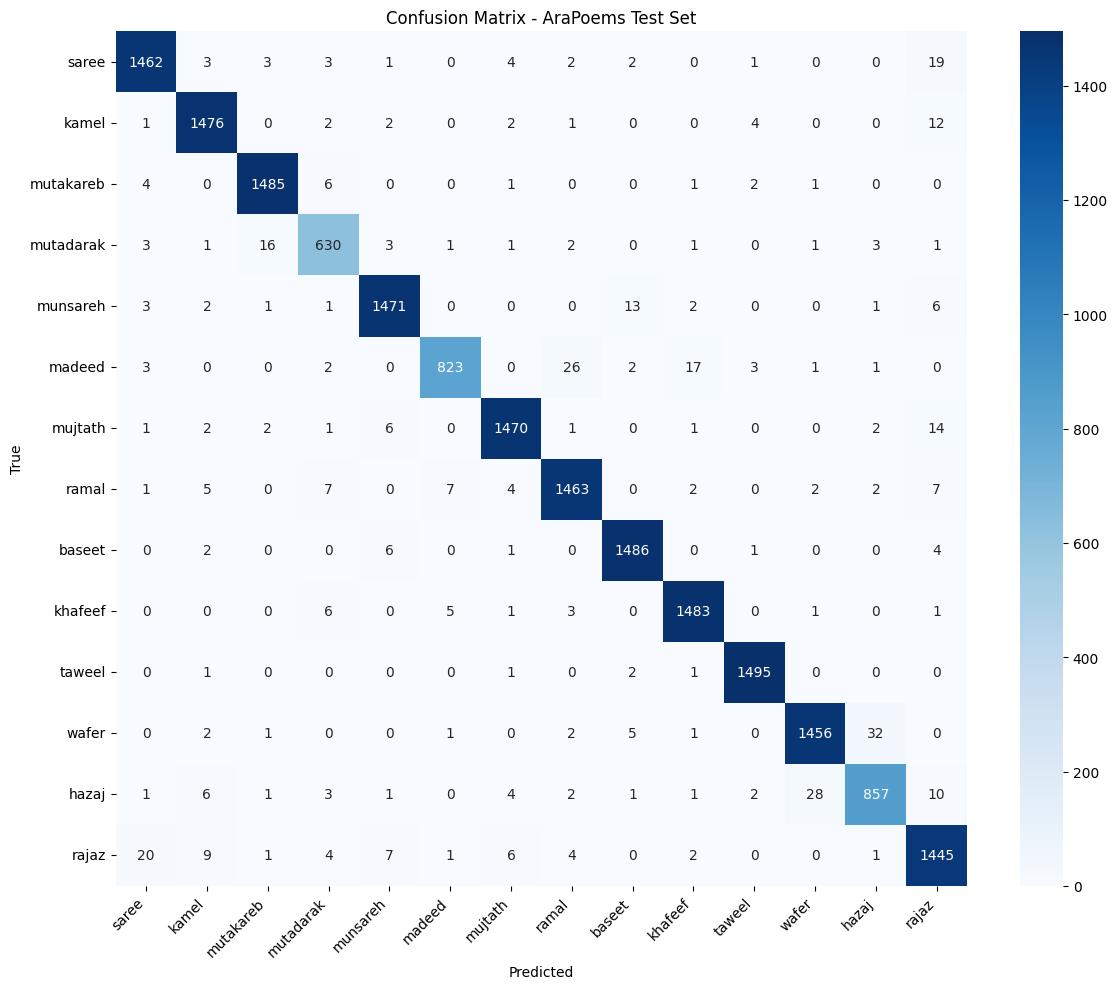


=== Comparison: MetRec vs AraPoems ===
Metric                   MetRec   AraPoems
Training Data            47,124    151,657
Test Accuracy            97.52% 97.59%
Test F1                  97.52% 97.59%


In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predict on test set
predictions = trainer.predict(test_dataset2)
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

# Overall metrics
print("=== AraPoems Model - Test Results ===")
print(f"Accuracy: {accuracy_score(true_labels, preds):.4f}")
print(f"F1 Score: {f1_score(true_labels, preds, average='weighted'):.4f}")

# Classification report
print("\n--- Classification Report ---")
print(classification_report(true_labels, preds, target_names=label_order))

# Confusion Matrix
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order)
plt.title("Confusion Matrix - AraPoems Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Compare with MetRec results
print("\n=== Comparison: MetRec vs AraPoems ===")
print(f"{'Metric':<20} {'MetRec':>10} {'AraPoems':>10}")
print(f"{'Training Data':<20} {'47,124':>10} {'151,657':>10}")
print(f"{'Test Accuracy':<20} {'97.52%':>10} {accuracy_score(true_labels, preds)*100:.2f}%")
print(f"{'Test F1':<20} {'97.52%':>10} {f1_score(true_labels, preds, average='weighted')*100:.2f}%")

## Optimized Training with Weighted Loss + Better Hyperparameters
- Weighted CrossEntropy to handle class imbalance
- Learning rate warmup
- Larger sample for underrepresented meters

In [9]:
import torch
import torch.nn as nn
from transformers import Trainer

# 1. Increase samples for rare meters
max_per_class = 15000
min_per_class = 10000  # Oversample rare classes

def balanced_sample(group):
    n = len(group)
    target = max(min(n, max_per_class), min_per_class)
    if n >= target:
        return group.sample(n=target, random_state=42)
    else:
        # Oversample: sample with replacement
        return group.sample(n=target, replace=True, random_state=42)

df_balanced2 = df_clean.groupby('label_name').apply(
    balanced_sample, include_groups=False
).reset_index(level=0).reset_index(drop=True)

# Rebuild label column
df_balanced2['label'] = df_balanced2['label_name'].map(label2id)

# Need verse column from the original index
df_balanced2 = df_clean.loc[
    df_clean.index.isin(df_balanced2.index) | True
].head(0)  # Reset approach

# Simpler approach: redo balanced sampling properly
df_balanced2 = pd.DataFrame()
for meter in label_order:
    meter_data = df_clean[df_clean['label_name'] == meter]
    n = len(meter_data)
    target = max(min(n, max_per_class), min_per_class)
    if n >= target:
        sampled = meter_data.sample(n=target, random_state=42)
    else:
        sampled = meter_data.sample(n=target, replace=True, random_state=42)
    df_balanced2 = pd.concat([df_balanced2, sampled])

df_balanced2 = df_balanced2.reset_index(drop=True)

print("--- Improved Balanced Dataset ---")
print(f"Total: {len(df_balanced2)}")
print(df_balanced2['label_name'].value_counts().sort_index())

--- Improved Balanced Dataset ---
Total: 195000
label_name
baseet       15000
hazaj        10000
kamel        15000
khafeef      15000
madeed       10000
mujtath      15000
munsareh     15000
mutadarak    10000
mutakareb    15000
rajaz        15000
ramal        15000
saree        15000
taweel       15000
wafer        15000
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np

# Split data
train_df3, temp_df3 = train_test_split(
    df_balanced2, test_size=0.2, random_state=42, stratify=df_balanced2['label']
)
val_df3, test_df3 = train_test_split(
    temp_df3, test_size=0.5, random_state=42, stratify=temp_df3['label']
)

print(f"Train: {len(train_df3)} | Val: {len(val_df3)} | Test: {len(test_df3)}")

# Calculate class weights (inverse frequency)
class_counts = train_df3['label'].value_counts().sort_index().values
total = len(train_df3)
class_weights = torch.tensor([total / (len(class_counts) * c) for c in class_counts], dtype=torch.float32)
print(f"\n--- Class Weights ---")
for i, label in enumerate(label_order):
    print(f"{label:12s}: {class_weights[i]:.3f}")

# Reload fresh model
model_name = "faisalq/bert-base-arapoembert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=14, ignore_mismatched_sizes=True
)

# Tokenize
def tokenize_function(examples):
    return tokenizer(examples["verse"], truncation=True, max_length=32, padding="max_length")

train_ds3 = Dataset.from_pandas(train_df3[['verse', 'label']].reset_index(drop=True))
val_ds3 = Dataset.from_pandas(val_df3[['verse', 'label']].reset_index(drop=True))
test_ds3 = Dataset.from_pandas(test_df3[['verse', 'label']].reset_index(drop=True))

train_ds3 = train_ds3.map(tokenize_function, batched=True)
val_ds3 = val_ds3.map(tokenize_function, batched=True)
test_ds3 = test_ds3.map(tokenize_function, batched=True)

train_ds3.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_ds3.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_ds3.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print("\nData ready!")

Train: 156000 | Val: 19500 | Test: 19500

--- Class Weights ---
saree       : 0.929
kamel       : 0.929
mutakareb   : 0.929
mutadarak   : 1.393
munsareh    : 0.929
madeed      : 1.393
mujtath     : 0.929
ramal       : 0.929
baseet      : 0.929
khafeef     : 0.929
taweel      : 0.929
wafer       : 0.929
hazaj       : 1.393
rajaz       : 0.929


Loading weights:   0%|          | 0/165 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: faisalq/bert-base-arapoembert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if yo

Map:   0%|          | 0/156000 [00:00<?, ? examples/s]

Map:   0%|          | 0/19500 [00:00<?, ? examples/s]

Map:   0%|          | 0/19500 [00:00<?, ? examples/s]


Data ready!


In [11]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import torch.nn as nn

# Custom Trainer with weighted loss
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")
    return {"accuracy": acc, "f1": f1}

# Optimized training arguments
training_args = TrainingArguments(
    output_dir="./arapoembert-optimized",
    num_train_epochs=5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=200,
    fp16=True,
    report_to="none",
    seed=42
)

# Initialize weighted trainer
trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_ds3,
    eval_dataset=val_ds3,
    compute_metrics=compute_metrics,
)

print("Starting optimized training with weighted loss...")
train_result = trainer.train()
print(f"\n--- Training Complete ---")
print(f"Training Loss: {train_result.training_loss:.4f}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting optimized training with weighted loss...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.138634,0.128145,0.974103,0.974104
2,0.088043,0.117160,0.977231,0.977225
3,0.060393,0.107267,0.979231,0.979229
4,0.048014,0.108703,0.980051,0.980053
5,0.026962,0.109671,0.980513,0.980522


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


--- Training Complete ---
Training Loss: 0.1571


=== Optimized Model - Test Results ===
Accuracy: 0.9838
F1 Score: 0.9839

--- Classification Report ---
              precision    recall  f1-score   support

       saree       0.99      0.98      0.99      1500
       kamel       0.98      0.99      0.98      1500
   mutakareb       0.99      0.99      0.99      1500
   mutadarak       0.98      0.99      0.99      1000
    munsareh       0.99      0.98      0.99      1500
      madeed       0.97      0.97      0.97      1000
     mujtath       0.98      0.99      0.98      1500
       ramal       0.97      0.98      0.98      1500
      baseet       0.99      0.99      0.99      1500
     khafeef       0.99      0.98      0.99      1500
      taweel       0.99      0.99      0.99      1500
       wafer       0.99      0.99      0.99      1500
       hazaj       0.98      0.98      0.98      1000
       rajaz       0.97      0.97      0.97      1500

    accuracy                           0.98     19500
   macro avg       0.98      0

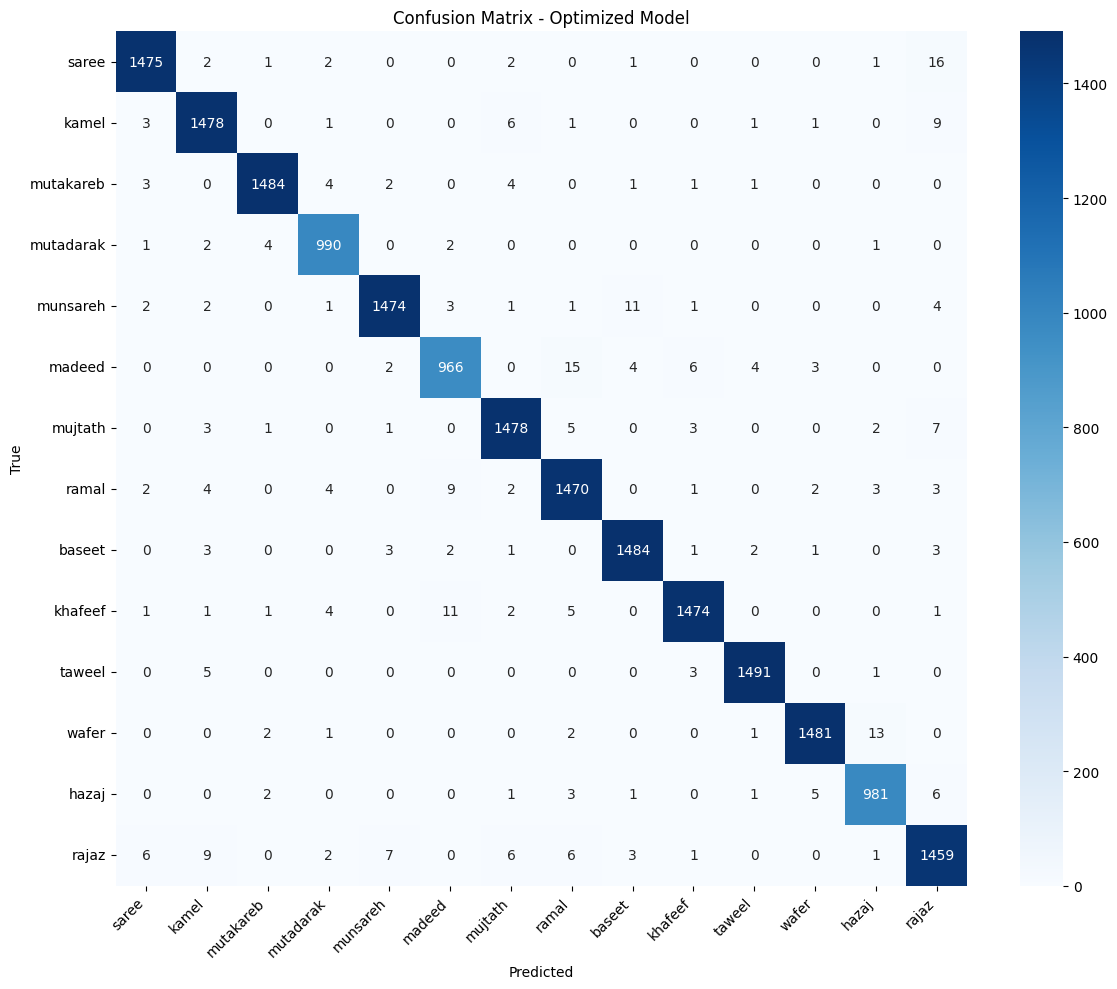


=== Full Comparison ===
Model                           Data   Accuracy         F1
MetRec Baseline                  47K     97.52%     97.52%
AraPoems Basic                  151K     97.59%     97.59%
AraPoems Optimized              156K 98.38%  98.39%


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on test set
predictions = trainer.predict(test_ds3)
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

# Overall metrics
print("=== Optimized Model - Test Results ===")
print(f"Accuracy: {accuracy_score(true_labels, preds):.4f}")
print(f"F1 Score: {f1_score(true_labels, preds, average='weighted'):.4f}")

# Classification report
print("\n--- Classification Report ---")
print(classification_report(true_labels, preds, target_names=label_order))

# Confusion Matrix
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order)
plt.title("Confusion Matrix - Optimized Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Full comparison
print("\n=== Full Comparison ===")
print(f"{'Model':<25} {'Data':>10} {'Accuracy':>10} {'F1':>10}")
print(f"{'MetRec Baseline':<25} {'47K':>10} {'97.52%':>10} {'97.52%':>10}")
print(f"{'AraPoems Basic':<25} {'151K':>10} {'97.59%':>10} {'97.59%':>10}")
print(f"{'AraPoems Optimized':<25} {'156K':>10} {accuracy_score(true_labels, preds)*100:.2f}%  {f1_score(true_labels, preds, average='weighted')*100:.2f}%")

## Final: Save Optimized Model & Interactive Testing

In [13]:
# Save optimized model to Drive
save_path = "/content/drive/MyDrive/arapoembert-meter-optimized"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

# Save labels
with open(f"{save_path}/labels.txt", "w", encoding="utf-8") as f:
    for label in label_order:
        f.write(label + "\n")

print(f"Model saved to: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/arapoembert-meter-optimized


In [14]:
import torch
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Meter names in Arabic
meter_arabic = {
    'saree': 'السريع', 'kamel': 'الكامل', 'mutakareb': 'المتقارب',
    'mutadarak': 'المتدارك', 'munsareh': 'المنسرح', 'madeed': 'المديد',
    'mujtath': 'المجتث', 'ramal': 'الرمل', 'baseet': 'البسيط',
    'khafeef': 'الخفيف', 'taweel': 'الطويل', 'wafer': 'الوافر',
    'hazaj': 'الهزج', 'rajaz': 'الرجز'
}

def classify_verse(verse):
    verse = verse.replace("#", " ").strip()
    inputs = tokenizer(verse, return_tensors="pt", truncation=True, max_length=32, padding="max_length")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)
    pred_id = torch.argmax(probs, dim=-1).item()
    confidence = probs[0][pred_id].item()
    return label_order[pred_id], confidence

def classify_poem(poem_text):
    verses = [v.strip() for v in poem_text.strip().split("\n") if v.strip()]
    print(f"{'='*60}")
    print(f"  عدد الأبيات: {len(verses)}")
    print(f"{'='*60}\n")

    predictions = []
    for i, verse in enumerate(verses):
        meter, conf = classify_verse(verse)
        predictions.append(meter)
        print(f"  بيت {i+1}: {verse[:70]}")
        print(f"  ← {meter_arabic[meter]} ({meter}) | الثقة: {conf:.1%}\n")

    vote = Counter(predictions).most_common(1)[0]
    print(f"{'='*60}")
    print(f"  النتيجة النهائية: {meter_arabic[vote[0]]} ({vote[0]})")
    print(f"  الأبيات المتفقة: {vote[1]}/{len(verses)}")
    print(f"{'='*60}")
    return vote[0]

In [16]:
# === Test 1: بحر الطويل - امرؤ القيس ===
print("\n اختبار 1: معلقة امرئ القيس\n")
classify_poem("""
قفا نبك من ذكرى حبيب ومنزل # بسقط اللوى بين الدخول فحومل
فتوضح فالمقراة لم يعف رسمها # لما نسجتها من جنوب وشمأل
ترى بعر الأرآم في عرصاتها # وقيعانها كأنه حب فلفل
""")

# === Test 2: بحر الكامل - المتنبي ===
print("\n اختبار 2: المتنبي\n")
classify_poem("""
على قدر أهل العزم تأتي العزائم # وتأتي على قدر الكرام المكارم
وتعظم في عين الصغير صغارها # وتصغر في عين العظيم العظائم
""")

# === Test 3: بحر البسيط ===
print("\n اختبار 3: أبو تمام - بحر البسيط\n")
classify_poem("""
السيف أصدق أنباء من الكتب # في حده الحد بين الجد واللعب
بيض الصفائح لا سود الصحائف في # متونهن جلاء الشك والريب
""")

# === Test 4: بحر الوافر ===
print("\n اختبار 4: بحر الوافر\n")
classify_poem("""
سلي إن جهلت الناس عنا وعنهم # فليس سواء عالم وجهول
إذا بلغ الفطام لنا صبي # تخر له الجبابر ساجدينا
""")

# === Test 5: بحر الخفيف ===
print("\n اختبار 5: بحر الخفيف\n")
classify_poem("""
لا تلم كفي إذا السيف نبا # صح مني العزم والدهر أبى
ليت شعري هل درى جيراننا # أي شخص بات فيهم وثوى
""")


 اختبار 1: معلقة امرئ القيس

  عدد الأبيات: 3

  بيت 1: قفا نبك من ذكرى حبيب ومنزل # بسقط اللوى بين الدخول فحومل
  ← الطويل (taweel) | الثقة: 99.9%

  بيت 2: فتوضح فالمقراة لم يعف رسمها # لما نسجتها من جنوب وشمأل
  ← الطويل (taweel) | الثقة: 99.8%

  بيت 3: ترى بعر الأرآم في عرصاتها # وقيعانها كأنه حب فلفل
  ← الطويل (taweel) | الثقة: 99.7%

  النتيجة النهائية: الطويل (taweel)
  الأبيات المتفقة: 3/3

 اختبار 2: المتنبي

  عدد الأبيات: 2

  بيت 1: على قدر أهل العزم تأتي العزائم # وتأتي على قدر الكرام المكارم
  ← الطويل (taweel) | الثقة: 99.9%

  بيت 2: وتعظم في عين الصغير صغارها # وتصغر في عين العظيم العظائم
  ← الطويل (taweel) | الثقة: 99.8%

  النتيجة النهائية: الطويل (taweel)
  الأبيات المتفقة: 2/2

 اختبار 3: أبو تمام - بحر البسيط

  عدد الأبيات: 2

  بيت 1: السيف أصدق أنباء من الكتب # في حده الحد بين الجد واللعب
  ← البسيط (baseet) | الثقة: 99.9%

  بيت 2: بيض الصفائح لا سود الصحائف في # متونهن جلاء الشك والريب
  ← البسيط (baseet) | الثقة: 99.9%

  النتيجة النهائية: البسيط (baseet

'ramal'

In [19]:
# Test WITHOUT # separator - each hemistich as separate line
print(" اختبار بدون # (كل شطر بسطر)\n")
classify_poem("""
كَأَنَّ السَرايا بَينَ قَوٍّ وَقارَةٍ
عَصائِبُ طَيرٍ يَنتَحَينَ لَمَشرَبِ
وَقَد كُنتُ أَخشى أَن أَموتَ وَلَم تَقُم
قَرائِبُ عَمروٍ وَسطَ نَوحٍ مُسَلِّبِ
شَفى النَفسَ مِنّي أَو دَنا مِن شِفائِها
تَرَدّيهُمُ مِن حالِقٍ مُتَصَوِّبِ
تَصيحُ الرُدَينِيّاتُ في حَجَباتِهِم
صِياحَ العَوالي في الثِقافِ المُثَقَّبِ
كَتائِبُ تُجزى فَوقَ كُلِّ كَتيبَةٍ
لِواءٌ كَظِلِّ الطائِرِ المُتَقَلِّبِ
""")

 اختبار بدون # (كل شطر بسطر)

  عدد الأبيات: 10

  بيت 1: كَأَنَّ السَرايا بَينَ قَوٍّ وَقارَةٍ
  ← الطويل (taweel) | الثقة: 99.9%

  بيت 2: عَصائِبُ طَيرٍ يَنتَحَينَ لَمَشرَبِ
  ← الطويل (taweel) | الثقة: 99.9%

  بيت 3: وَقَد كُنتُ أَخشى أَن أَموتَ وَلَم تَقُم
  ← الطويل (taweel) | الثقة: 99.9%

  بيت 4: قَرائِبُ عَمروٍ وَسطَ نَوحٍ مُسَلِّبِ
  ← الطويل (taweel) | الثقة: 99.9%

  بيت 5: شَفى النَفسَ مِنّي أَو دَنا مِن شِفائِها
  ← الطويل (taweel) | الثقة: 99.9%

  بيت 6: تَرَدّيهُمُ مِن حالِقٍ مُتَصَوِّبِ
  ← الطويل (taweel) | الثقة: 46.1%

  بيت 7: تَصيحُ الرُدَينِيّاتُ في حَجَباتِهِم
  ← الطويل (taweel) | الثقة: 99.9%

  بيت 8: صِياحَ العَوالي في الثِقافِ المُثَقَّبِ
  ← الطويل (taweel) | الثقة: 99.9%

  بيت 9: كَتائِبُ تُجزى فَوقَ كُلِّ كَتيبَةٍ
  ← الطويل (taweel) | الثقة: 99.9%

  بيت 10: لِواءٌ كَظِلِّ الطائِرِ المُتَقَلِّبِ
  ← الطويل (taweel) | الثقة: 99.9%

  النتيجة النهائية: الطويل (taweel)
  الأبيات المتفقة: 10/10


'taweel'

## How to Use This Model Project

### Prerequisites:
```python
pip install transformers torch
```

### Loading the Model:
```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_path = "/content/drive/MyDrive/arapoembert-meter-optimized"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()
```

### Input Preprocessing Pipeline:

**Step 1: Receive the raw poem text**
- The input can be a single verse, two verses, or a full poem
- Can be with or without diacritics (tashkeel)
- Can use `#` between hemistichs or not

**Step 2: Clean the text**
- Replace `#` separator with a space
- Remove extra whitespace
- Strip leading/trailing spaces

**Step 3: Split into individual verses**
- Split the poem by newlines (`\n`)
- Remove empty lines
- Each line = one verse (or one hemistich)

**Step 4: Tokenize each verse**
- Tokenizer: AraPoemBERT WordPiece (vocab = 50,000)
- Max length: 32 tokens (sufficient for any Arabic verse)
- Padding: pad to max_length with zeros
- Truncation: truncate if exceeds 32 tokens

**Step 5: Model inference**
- Pass tokenized input through AraPoemBERT (10 encoder layers)
- Classification head outputs 14 probabilities (one per meter)
- Select the meter with highest probability

**Step 6: Majority voting (for multi-verse input)**
- Collect predictions from all verses
- The most frequent meter = final classification
- Report confidence as (agreeing verses / total verses)

### Complete Function Ready to Copy:
```python
from collections import Counter

labels = ['saree', 'kamel', 'mutakareb', 'mutadarak', 'munsareh',
          'madeed', 'mujtath', 'ramal', 'baseet', 'khafeef',
          'taweel', 'wafer', 'hazaj', 'rajaz']

meter_arabic = {
    'saree': 'السريع', 'kamel': 'الكامل', 'mutakareb': 'المتقارب',
    'mutadarak': 'المتدارك', 'munsareh': 'المنسرح', 'madeed': 'المديد',
    'mujtath': 'المجتث', 'ramal': 'الرمل', 'baseet': 'البسيط',
    'khafeef': 'الخفيف', 'taweel': 'الطويل', 'wafer': 'الوافر',
    'hazaj': 'الهزج', 'rajaz': 'الرجز'
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def classify_poem(poem_text):
    # Step 1-3: Clean and split
    verses = [v.replace("#", " ").strip() for v in poem_text.strip().split("\n") if v.strip()]

    # Step 4-5: Tokenize and predict each verse
    predictions = []
    for verse in verses:
        inputs = tokenizer(verse, return_tensors="pt", truncation=True, max_length=32, padding="max_length")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred_id = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][pred_id].item()
        predictions.append((labels[pred_id], confidence))

    # Step 6: Majority voting
    meter_votes = [p[0] for p in predictions]
    final_meter = Counter(meter_votes).most_common(1)[0][0]
    agreement = Counter(meter_votes).most_common(1)[0][1]

    return {
        "meter_en": final_meter,
        "meter_ar": meter_arabic[final_meter],
        "agreement": f"{agreement}/{len(verses)}",
        "verse_predictions": predictions
    }
```

### Example Usage:
```python
result = classify_poem("قفا نبك من ذكرى حبيب ومنزل # بسقط اللوى بين الدخول فحومل")
print(result["meter_ar"])  # الطويل
```

### Model Specs:
| Property | Value |
|----------|-------|
| Base Model | AraPoemBERT (faisalq/bert-base-arapoembert) |
| Architecture | BERT (10 layers, 768 hidden, 12 heads) |
| Vocab Size | 50,000 tokens |
| Max Sequence Length | 32 tokens |
| Number of Classes | 14 meters |
| Training Data | AraPoems (195,000 verses, all eras) |
| Test Accuracy | 98.38% |
| Test F1 Score | 98.39% |
| Loss Function | Weighted CrossEntropy |
| Optimizer | AdamW (lr=3e-5, weight_decay=0.01) |
| LR Scheduler | Cosine with warmup (10%) |